<a href="https://colab.research.google.com/github/abigailcrowo/DS3001-SP26/blob/main/scraping_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(13, 6)
                                               title    price    year  \
0                           1988 sunbeam 34 sailboat  39500.0  1988.0   
1  1994 14.5ft northwood 1467lw boat + boat trail...   4500.0  1994.0   
2             wave armor drive on pwc and boat ports   2200.0     NaN   
3                                           baja h2x  25000.0     NaN   
4                 2-person pelican unison 136t kayak    220.0     NaN   

                                                link    brand   age  
0  https://charlottesville.craigslist.org/boa/d/d...  missing  37.0  
1  https://charlottesville.craigslist.org/boa/d/m...  missing  31.0  
2  https://charlottesville.craigslist.org/boa/d/g...  missing   NaN  
3  https://charlottesville.craigslist.org/boa/d/v...  missing   NaN  
4  https://charlottesville.craigslist.org/boa/d/c...  missing   NaN  


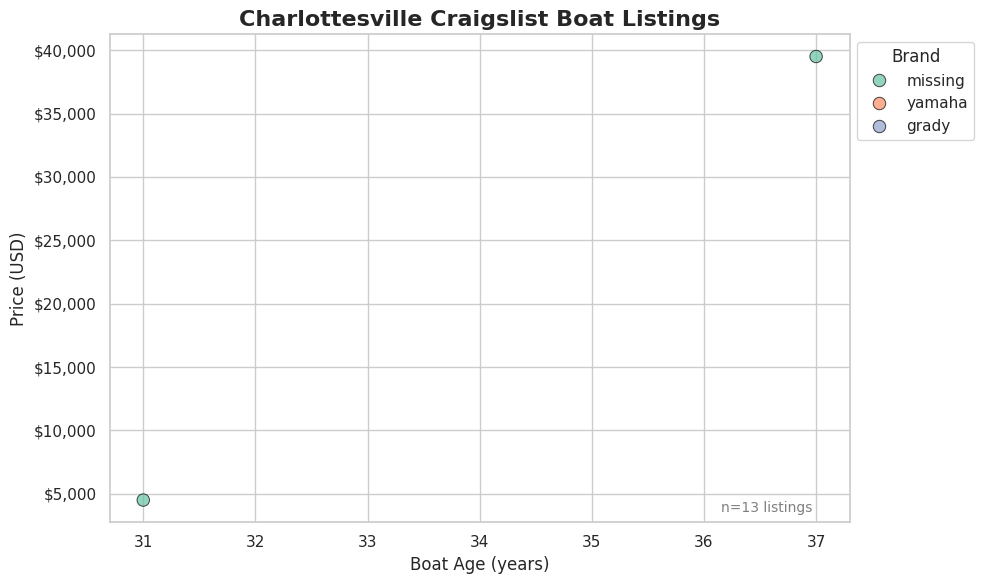

count       13.000000
mean      7078.461538
std      11793.654259
min          0.000000
25%        600.000000
50%       2200.000000
75%       6500.000000
max      39500.000000
Name: price, dtype: float64


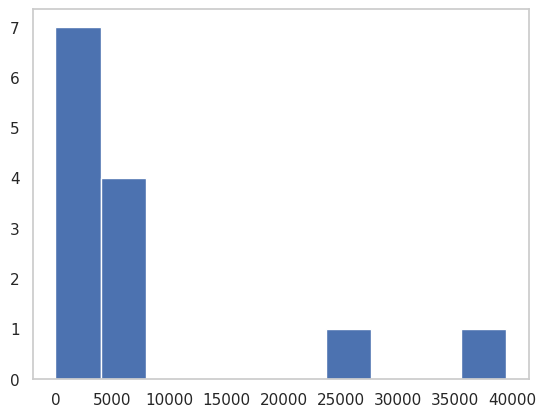

count     2.000000
mean     34.000000
std       4.242641
min      31.000000
25%      32.500000
50%      34.000000
75%      35.500000
max      37.000000
Name: age, dtype: float64


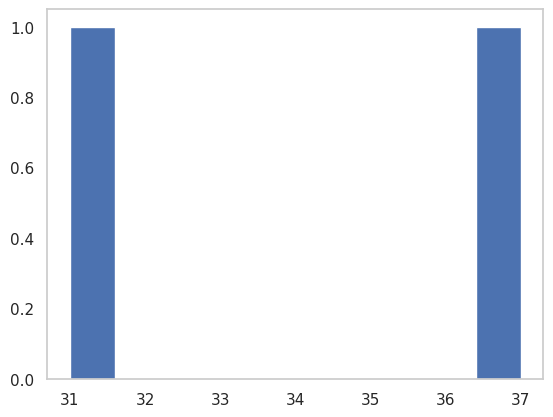

        price                                                             \
        count         mean           std     min     25%     50%     75%   
brand                                                                      
grady     1.0  6500.000000           NaN  6500.0  6500.0  6500.0  6500.0   
missing  11.0  7183.636364  12916.239602     0.0   410.0  1500.0  4625.0   
yamaha    1.0  6500.000000           NaN  6500.0  6500.0  6500.0  6500.0   

                  
             max  
brand             
grady     6500.0  
missing  39500.0  
yamaha    6500.0  
          age                                              
        count  mean       std   min   25%   50%   75%   max
brand                                                      
grady     0.0   NaN       NaN   NaN   NaN   NaN   NaN   NaN
missing   2.0  34.0  4.242641  31.0  32.5  34.0  35.5  37.0
yamaha    0.0   NaN       NaN   NaN   NaN   NaN   NaN   NaN


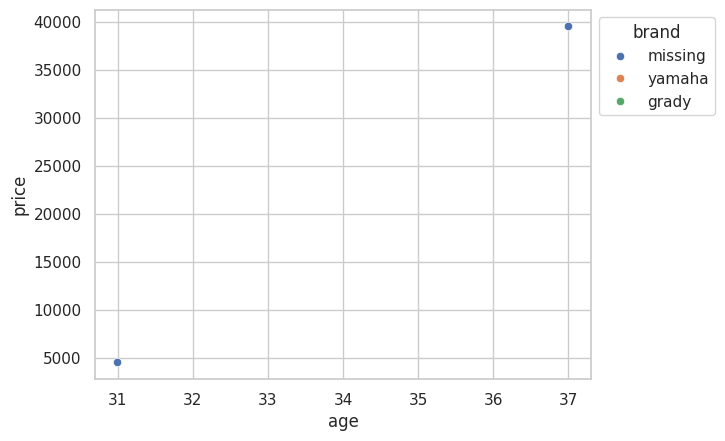

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


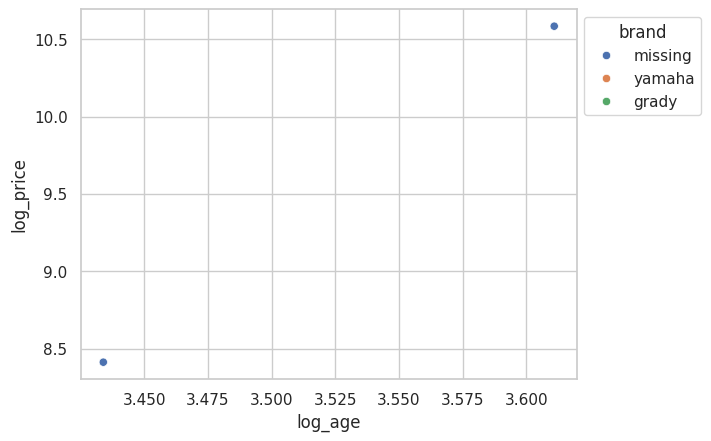

           log_price   log_age
log_price   3.059285  0.192167
log_age     0.192167  0.015652
           log_price  log_age
log_price        1.0      1.0
log_age          1.0      1.0


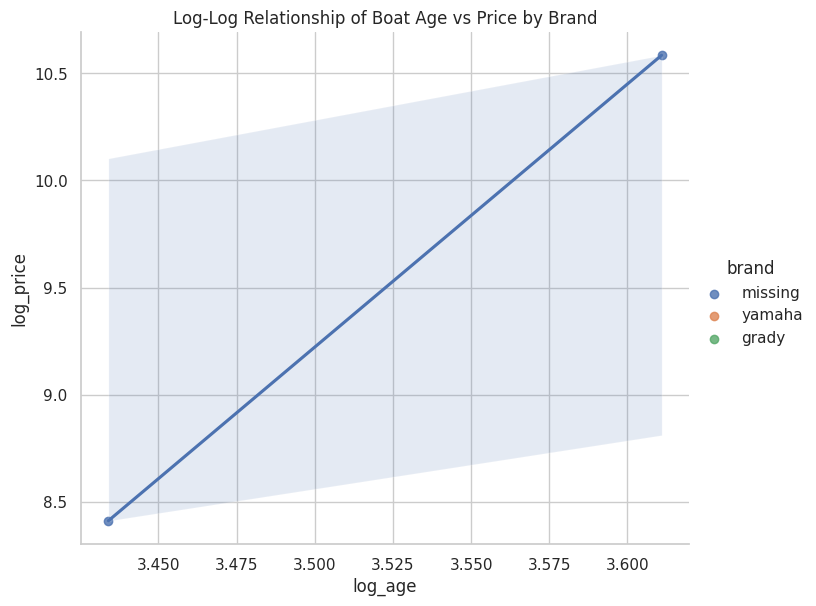

           log_price   log_age
log_price   3.059285  0.192167
log_age     0.192167  0.015652
           log_price  log_age
log_price        1.0      1.0
log_age          1.0      1.0


In [3]:
#I used Copilot to help me


import os
import re
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup

# Ensure output folder exists
os.makedirs('./src', exist_ok=True)

# Request setup
URL = 'https://charlottesville.craigslist.org/search/boo?purveyor=owner'
HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) '
        'Gecko/20100101 Firefox/124.0'
    )
}

# Fetch raw HTML
response = requests.get(URL, headers=HEADERS)
soup_obj = BeautifulSoup(response.content, 'html.parser')
listings = soup_obj.find_all(class_="cl-static-search-result")

# Known boat brands
BRANDS = [
    'yamaha', 'bayliner', 'sea', 'ray', 'tracker', 'lund', 'carver',
    'mastercraft', 'chaparral', 'regal', 'hatteras', 'bertram',
    'grady', 'white', 'cobalt', 'malibu', 'sailfish', 'boston', 'whaler'
]

# Parse listings
data = []
for listing in listings:
    title = listing.find('div', class_='title').get_text().lower()
    price = listing.find('div', class_='price').get_text()
    link = listing.find(href=True)['href']

    # Extract brand
    words = title.split()
    brand_hits = [word for word in words if word in BRANDS]
    brand = brand_hits[0] if brand_hits else 'missing'

    # Extract year
    year_match = re.search(r'20[0-9]{2}|19[0-9]{2}', title)
    year = year_match.group(0) if year_match else np.nan

    data.append({
        'title': title,
        'price': price,
        'year': year,
        'link': link,
        'brand': brand
    })

# Wrangle data
df = pd.DataFrame(data)
df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['age'] = 2025 - df['year']

# Save to CSV
df.to_csv('./src/craigslist_cville_boats.csv', index=False)
print(df.shape)
print(df.head())


# Set theme
sns.set_theme(style="whitegrid")

# Create scatterplot
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=df,
    x='age',
    y='price',
    hue='brand',
    palette='Set2',
    s=80,
    alpha=0.7,
    edgecolor='black'
)

# Customize labels and title
ax.set_title("Charlottesville Craigslist Boat Listings", fontsize=16, weight='bold')
ax.set_xlabel("Boat Age (years)", fontsize=12)
ax.set_ylabel("Price (USD)", fontsize=12)

# Format y-axis with commas
ax.get_yaxis().set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"${int(x):,}")
)

# Move legend outside
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="Brand")

# Add annotation for sample size
plt.text(
    0.95, 0.02,
    f"n={df.shape[0]} listings",
    transform=plt.gca().transAxes,
    ha="right", fontsize=10, color="gray"
)

plt.tight_layout()
plt.show()


# Price distribution
print(df['price'].describe())
df['price'].hist(grid=False)
plt.show()

# Age distribution
print(df['age'].describe())
df['age'].hist(grid=False)
plt.show()

# Grouped summaries
print(df[['price', 'brand']].groupby('brand').describe())
print(df[['age', 'brand']].groupby('brand').describe())

# Scatterplot: Age vs Price
ax = sns.scatterplot(data=df, x='age', y='price', hue='brand')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

# Log transforms
df['log_price'] = np.log(df['price'])
df['log_age'] = np.log(df['age'])

# Scatterplot: Log-Log Age vs Price
ax = sns.scatterplot(data=df, x='log_age', y='log_price', hue='brand')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

# Covariance and correlation
print(df[['log_price', 'log_age']].cov())
print(df[['log_price', 'log_age']].corr())

# Regression plot
sns.lmplot(data=df, x='log_age', y='log_price', hue='brand', height=6, aspect=1.2)
plt.title("Log-Log Relationship of Boat Age vs Price by Brand")
plt.show()

print(df[['log_price', 'log_age']].cov())
print(df[['log_price', 'log_age']].corr())


Key takeaways:
*There is a pretty large disribution in prices
*Some boats were significantly higher priced than majority, skewing the data. So, because of these signifcantly different data points, the median is a better way to measure the data.
*There are very minimal new boats.
*Older boats are cheaper.
